# 1. Imports


In [1]:
import os
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from tensorflow.keras.preprocessing.image import ImageDataGenerator, apply_affine_transform
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 2. Setting Up the Dataset Path

In [2]:
print(os.getcwd())
BASE_DIR = os.getcwd()
DATADIR = os.path.join(BASE_DIR, "dataset")


c:\Users\Somaya Ahmad\Desktop\Kidney_stone_detection-


 # 3. Preview One Image Per Category

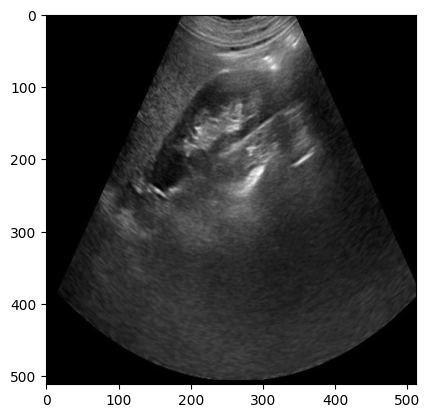

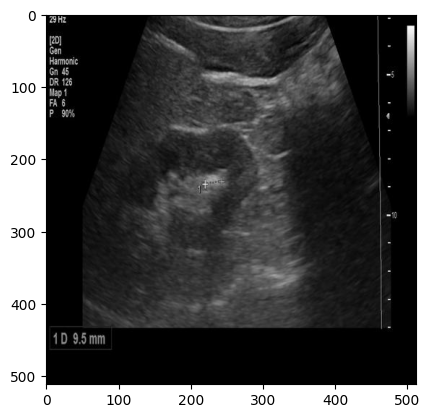

In [3]:

CATEGORIES = ["Normal", "stone"]  # Normal=0, stone=1
for category in CATEGORIES:
    path = os.path.join(DATADIR, category)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array, cmap="gray")
        plt.show()
        break

# 4. Resize the Image

Original Image shape: (512, 512)
Resized Image shape: (224, 224)


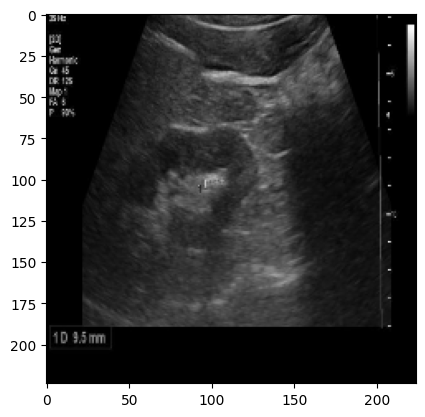

In [4]:
print("Original Image shape:", img_array.shape)  # original size
IMG_SIZE = 224
new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array, cmap="gray")
print("Resized Image shape:", new_array.shape)  # resized image
plt.show()

# 5. Build the Training Dataset

In [5]:
training_data = []
def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)
        class_num = CATEGORIES.index(category)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                print(f"Error processing image {img}: {e}")

create_training_data()
print(len(training_data))  # total number of images loaded

2000


#  6. Shuffle & Separate Features/Labels

In [6]:
random.shuffle(training_data)   # prevents the model from learning order

X = []  # features (images)
y = []  # labels (0 or 1)

for feature, label in training_data:
    X.append(feature)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(y)

# 7. Save with Pickle
##### Pickle saves Python objects to disk so you don't re-process images every time

In [7]:
import pickle

# Save X (images)
pickle_out = open("X.pickle", "wb")   # "wb" = write binary
pickle.dump(X, pickle_out)
pickle_out.close()

# Save y (labels)
pickle_out = open("y.pickle", "wb")
pickle.dump(y, pickle_out)
pickle_out.close()

# 8. Load Pickle Back

In [8]:
pickle_in = open("X.pickle", "rb")   # "rb" = read binary
X = pickle.load(pickle_in)

pickle_in = open("y.pickle", "rb")
y = pickle.load(pickle_in)

# 9. Normalize the Images


In [9]:
X = X.astype("float32") / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


# 10. Split Dataset into Training, Validation& Testing (70,15,15)

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1400, 224, 224, 1)
Validation data shape: (300, 224, 224, 1)
Testing data shape: (300, 224, 224, 1)


 # 11. Data Augmentation

In [11]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

# 12. Visualize Augmented Images

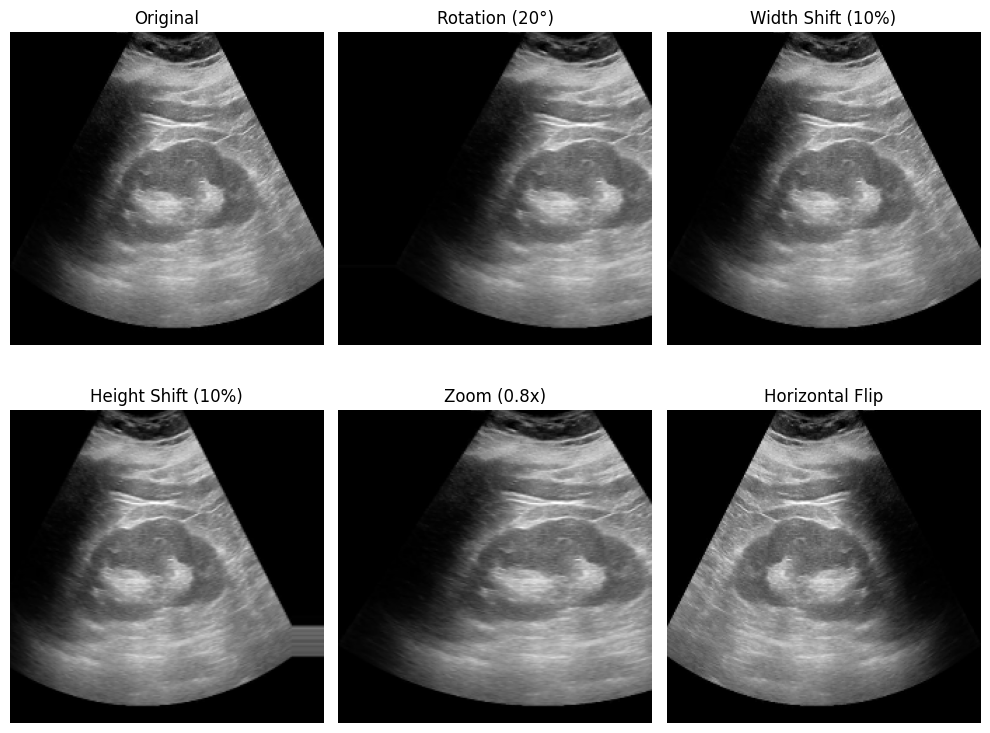

In [12]:
img = X_train[0]  # shape = (225, 225, 1)

plt.figure(figsize=(10,8))

# Original
plt.subplot(2,3,1)
plt.imshow(img.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Original")
plt.axis("off")

# Rotation
rot = apply_affine_transform(img, theta=20)
plt.subplot(2,3,2)
plt.imshow(rot.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Rotation (20°)")
plt.axis("off")

# Width shift (horizontal)
width_shift = apply_affine_transform(img, tx=IMG_SIZE * 0.1)
plt.subplot(2,3,3)
plt.imshow(width_shift.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Width Shift (10%)")
plt.axis("off")

# Height shift (vertical)
height_shift = apply_affine_transform(img, ty=IMG_SIZE * 0.1)
plt.subplot(2,3,4)
plt.imshow(height_shift.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Height Shift (10%)")
plt.axis("off")

# Zoom
zoom = apply_affine_transform(img, zx=0.8, zy=0.8)
plt.subplot(2,3,5)
plt.imshow(zoom.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Zoom (0.8x)")
plt.axis("off")

# Flip
flip = np.fliplr(img.reshape(IMG_SIZE, IMG_SIZE))
plt.subplot(2,3,6)
plt.imshow(flip, cmap='gray')
plt.title("Horizontal Flip")
plt.axis("off")

plt.tight_layout()
plt.show()

# 13. Create and Save Augmented Training Data

In [13]:
AUGMENTATIONS_PER_IMAGE = 2

X_train_augmented = []
y_train_augmented = []

for i in range(len(X_train)):
    image = X_train[i]
    label = y_train[i]

    X_train_augmented.append(image)
    y_train_augmented.append(label)

    image_batch = np.expand_dims(image, axis=0)

    aug_iter = train_datagen.flow(image_batch, batch_size=1)

    for _ in range(AUGMENTATIONS_PER_IMAGE):
        aug_image = next(aug_iter)[0]
        X_train_augmented.append(aug_image)
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented, dtype="float32")
y_train_augmented = np.array(y_train_augmented)

print("Original training size:", len(X_train))
print("Augmented training size:", len(X_train_augmented))
print("Increase:", len(X_train_augmented) / len(X_train), "x")

Original training size: 1400
Augmented training size: 4200
Increase: 3.0 x


# 14. Save Augmented Images to Dataset Folder

In [14]:

AUGMENTED_DIR = os.path.join(DATADIR, "augmented")

for category in CATEGORIES:
    os.makedirs(os.path.join(AUGMENTED_DIR, category), exist_ok=True)

for i, (image, label) in enumerate(zip(X_train_augmented, y_train_augmented)):
    category = CATEGORIES[label]

    image_to_save = image.reshape(IMG_SIZE, IMG_SIZE)

    # Convert from normalized 0-1 back to 0-255
    image_to_save = (image_to_save * 255).astype("uint8")

    save_path = os.path.join(
        AUGMENTED_DIR,
        category,
        f"augmented_{i}.png"
    )

    cv2.imwrite(save_path, image_to_save)

print("Augmented images saved to:", AUGMENTED_DIR)

Augmented images saved to: c:\Users\Somaya Ahmad\Desktop\Kidney_stone_detection-\dataset\augmented


# 15. Save Augmented Data with pickles

In [15]:
with open("X_train_augmented.pickle", "wb") as pickle_out:
    pickle.dump(X_train_augmented, pickle_out)

with open("y_train_augmented.pickle", "wb") as pickle_out:
    pickle.dump(y_train_augmented, pickle_out)

print("Augmented data saved successfully.")

Augmented data saved successfully.


# 16. Optimized Grayscale CNN Model

## 16.1. Build CNN Function for Hyperparameter Search

In [16]:
def build_cnn_model(conv_layers, filters, dense_units, dropout_rate, learning_rate):
    model = Sequential()

    model.add(Conv2D(filters, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    for _ in range(conv_layers - 1):
        model.add(Conv2D(filters, (3, 3), activation="relu"))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(GlobalAveragePooling2D())

    model.add(Dense(dense_units, activation="relu"))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 16.2. Hyperparameter Search 

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

BATCH_SIZE = 16
EPOCHS = 10

conv_layers_options = [2, 3]
filters_options = [32]
dense_units_options = [64, 128]
dropout_options = [0.5]
learning_rate_options = [0.0001]

best_val_accuracy = 0
best_model = None
best_params = None
results = []

for conv_layers in conv_layers_options:
    for filters in filters_options:
        for dense_units in dense_units_options:
            for dropout_rate in dropout_options:
                for learning_rate in learning_rate_options:

                    print("\nTraining model with:")
                    print("conv_layers:", conv_layers)
                    print("filters:", filters)
                    print("dense_units:", dense_units)
                    print("dropout_rate:", dropout_rate)
                    print("learning_rate:", learning_rate)

                    model = build_cnn_model(
                        conv_layers=conv_layers,
                        filters=filters,
                        dense_units=dense_units,
                        dropout_rate=dropout_rate,
                        learning_rate=learning_rate
                    )

                    checkpoint = ModelCheckpoint(
                        "best_epoch_checkpoint.keras",
                        monitor="val_accuracy",
                        save_best_only=True,
                        mode="max",
                        verbose=0
                    )

                    train_generator = train_datagen.flow(
                        X_train,
                        y_train,
                        batch_size=BATCH_SIZE,
                        shuffle=True
                    )

                    history = model.fit(
                        train_generator,
                        validation_data=(X_val, y_val),
                        epochs=EPOCHS,
                        callbacks=[checkpoint],
                        verbose=1
                    )

                    best_epoch_model = load_model("best_epoch_checkpoint.keras")
                    val_loss, val_accuracy = best_epoch_model.evaluate(X_val, y_val, verbose=0)

                    results.append([
                        conv_layers,
                        filters,
                        dense_units,
                        dropout_rate,
                        learning_rate,
                        val_accuracy
                    ])

                    print("Validation Accuracy:", val_accuracy)

                    if val_accuracy > best_val_accuracy:
                        best_val_accuracy = val_accuracy
                        best_model = best_epoch_model
                        best_params = {
                            "conv_layers": conv_layers,
                            "filters": filters,
                            "dense_units": dense_units,
                            "dropout_rate": dropout_rate,
                            "learning_rate": learning_rate
                        }

print("\nBest Validation Accuracy:", best_val_accuracy)
print("Best Parameters:", best_params)


Training model with:
conv_layers: 2
filters: 32
dense_units: 64
dropout_rate: 0.5
learning_rate: 0.0001


c:\Users\Somaya Ahmad\Desktop\Kidney_stone_detection-\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.7050 - loss: 0.5967 - val_accuracy: 0.5900 - val_loss: 0.6859
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.7864 - loss: 0.5023 - val_accuracy: 0.7867 - val_loss: 0.6691
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8029 - loss: 0.4694 - val_accuracy: 0.7233 - val_loss: 0.6494
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.8164 - loss: 0.4425 - val_accuracy: 0.7467 - val_loss: 0.6210
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8300 - loss: 0.4188 - val_accuracy: 0.7833 - val_loss: 0.5745
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.8457 - loss: 0.3914 - val_accuracy: 0.8533 - val_loss: 0.4910
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.8536 - loss: 0.3832 - val_accuracy: 0.9133 - val_loss: 0.3793
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.8843 - loss: 0.3475 - val_accuracy: 0.9367 - v

## 16.3. Save Best Model

In [18]:
best_model.save("best_grayscale_cnn_model.keras")
print("Best model saved as best_grayscale_cnn_model.keras")

Best model saved as best_grayscale_cnn_model.keras


## 16.4. Best Model Summary

In [19]:
print("=" * 50)
print("BEST MODEL PARAMETERS")
print("=" * 50)
print(best_params)

print("\n" + "=" * 50)
print("BEST MODEL SUMMARY")
print("=" * 50)
best_model.summary()

BEST MODEL PARAMETERS
{'conv_layers': 3, 'filters': 32, 'dense_units': 64, 'dropout_rate': 0.5, 'learning_rate': 0.0001}

BEST MODEL SUMMARY


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,749 (249.02 KB)

 Trainable params: 21,185 (82.75 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 42,372 (165.52 KB)

## 16.5. Evaluate Best Model on Test Set

In [20]:
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

print("=" * 50)
print("BEST MODEL TEST RESULTS")
print("=" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step - accuracy: 0.9700 - loss: 0.1735
BEST MODEL TEST RESULTS
Test Loss: 0.1735
Test Accuracy: 0.9700


## 16.6. Predictions

In [21]:
y_pred_prob = best_model.predict(X_test)
y_pred_classes = (y_pred_prob > 0.5).astype("int32")

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 339ms/step


## 16.7. Show Actual Predictions on Test Images (12 random images)

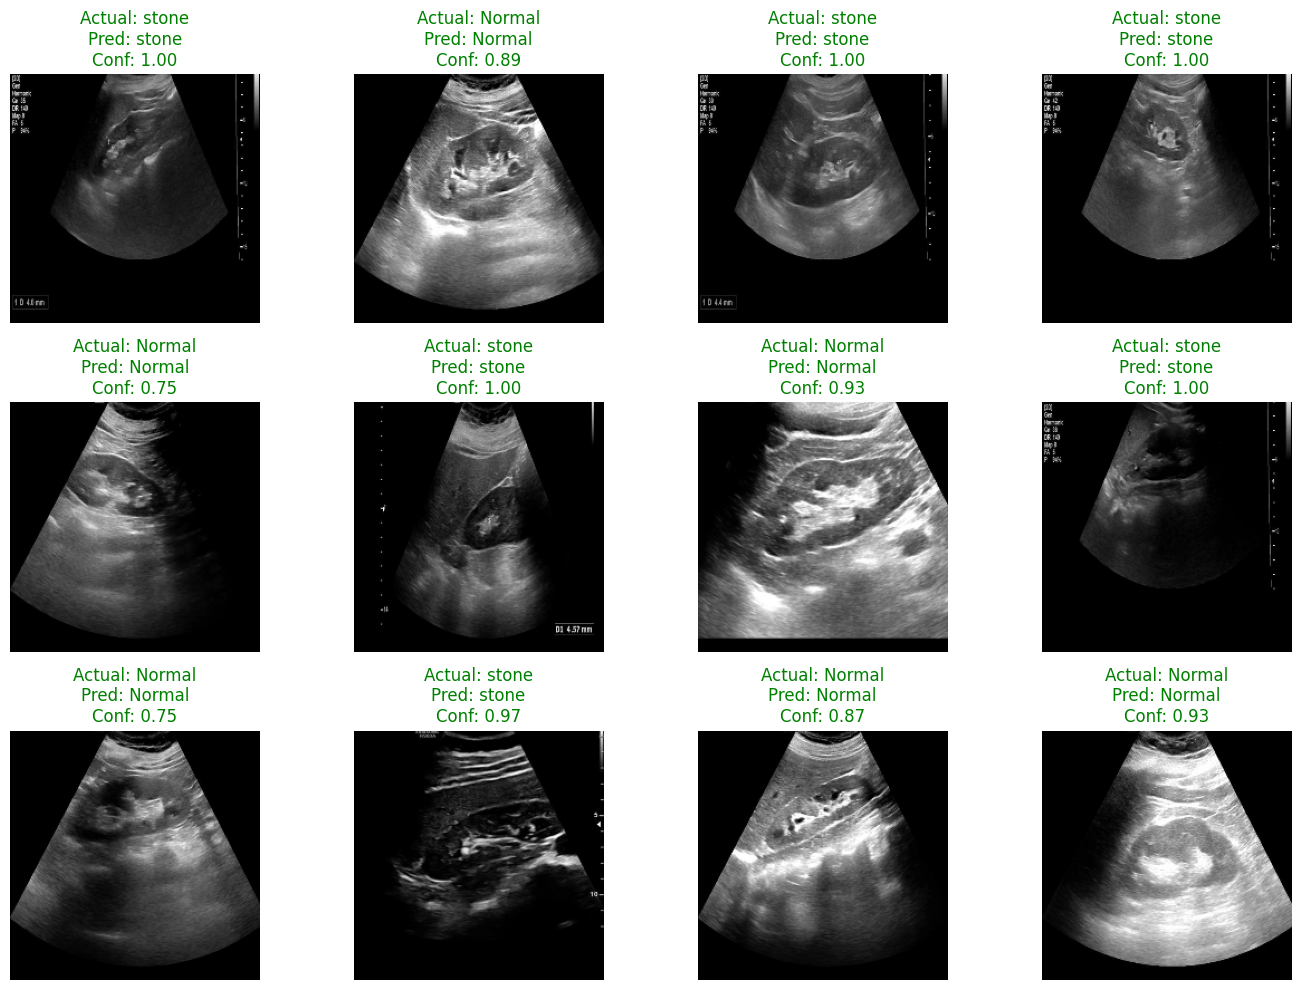

In [22]:

NUM_IMAGES = 12
random_indices = np.random.choice(len(X_test), size=min(NUM_IMAGES, len(X_test)), replace=False)

plt.figure(figsize=(14, 10))

for plot_index, i in enumerate(random_indices):
    image = X_test[i].reshape(IMG_SIZE, IMG_SIZE)

    actual_label = CATEGORIES[y_test[i]]
    predicted_class = int(y_pred_classes[i][0])
    predicted_label = CATEGORIES[predicted_class]

    confidence = y_pred_prob[i][0]

    if predicted_class == 0:
        confidence_to_show = 1 - confidence
    else:
        confidence_to_show = confidence

    color = "green" if actual_label == predicted_label else "red"

    plt.subplot(3, 4, plot_index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Actual: {actual_label}\nPred: {predicted_label}\nConf: {confidence_to_show:.2f}",
        color=color
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 16.8. Best Model Parameters Box

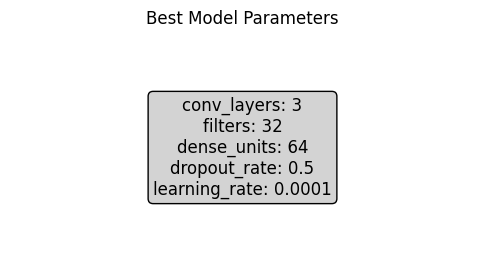

In [23]:


params_text = "\n".join([f"{key}: {value}" for key, value in best_params.items()])

plt.figure(figsize=(6, 3))
plt.text(
    0.5,
    0.5,
    params_text,
    fontsize=12,
    ha="center",
    va="center",
    bbox=dict(
        boxstyle="round",
        facecolor="lightgray",
        edgecolor="black"
    )
)

plt.title("Best Model Parameters")
plt.axis("off")
plt.show()

## 16.9. Confusion Matrix Graph

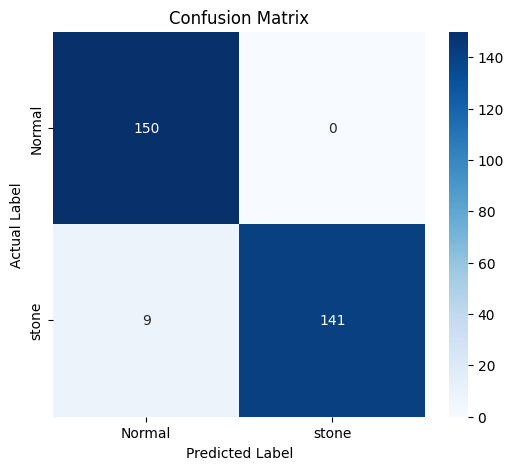

In [24]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CATEGORIES,
    yticklabels=CATEGORIES
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## 16.10. ROC Curve Graph

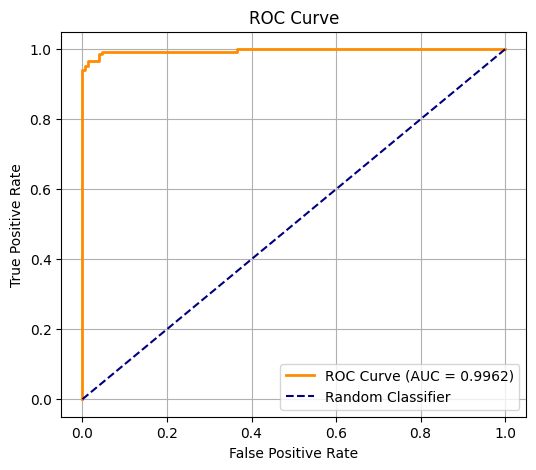

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 17. MobileNetV2 Using Saved Augmented Training Data

## 17.1. Prepare Validation and Test Data for MobileNetV2

In [26]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.utils import Sequence

X_val_rgb = np.repeat(X_val, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

X_val_mobile = preprocess_input(X_val_rgb * 255.0)
X_test_mobile = preprocess_input(X_test_rgb * 255.0)

print("MobileNetV2 validation shape:", X_val_mobile.shape)
print("MobileNetV2 testing shape:", X_test_mobile.shape)

MobileNetV2 validation shape: (300, 224, 224, 3)
MobileNetV2 testing shape: (300, 224, 224, 3)


## 17.2. Create Batch Generator for Augmented MobileNetV2 Training Data

In [27]:

class MobileNetAugmentedGenerator(Sequence):
    def __init__(self, X, y, batch_size=16, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.X))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[
            index * self.batch_size:(index + 1) * self.batch_size
        ]

        batch_x = self.X[batch_indices]
        batch_y = self.y[batch_indices]

        batch_x_rgb = np.repeat(batch_x, 3, axis=-1)
        batch_x_mobile = preprocess_input(batch_x_rgb * 255.0)

        return batch_x_mobile, batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

## 17.3. Build MobileNetV2 Model

In [28]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model_mobilenet = Model(inputs=base_model.input, outputs=output)

## 17.4. Compile MobileNetV2

In [29]:
model_mobilenet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_mobilenet.summary()

Model: "functional_92"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 17.5. Train MobileNetV2 with Augmented Data Generator

In [30]:


BATCH_SIZE_MOBILE = 16

mobile_train_generator = MobileNetAugmentedGenerator(
    X_train_augmented,
    y_train_augmented,
    batch_size=BATCH_SIZE_MOBILE,
    shuffle=True
)

early_stop_mobile = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_mobilenet = model_mobilenet.fit(
    mobile_train_generator,
    validation_data=(X_val_mobile, y_val),
    epochs=10,
    callbacks=[early_stop_mobile],
    verbose=1
)

c:\Users\Somaya Ahmad\Desktop\Kidney_stone_detection-\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 186s 654ms/step - accuracy: 0.8483 - loss: 0.3461 - val_accuracy: 0.9900 - val_loss: 0.1083
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 179s 681ms/step - accuracy: 0.9519 - loss: 0.1473 - val_accuracy: 0.9933 - val_loss: 0.0582
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 163s 618ms/step - accuracy: 0.9667 - loss: 0.1031 - val_accuracy: 0.9933 - val_loss: 0.0395
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 164s 623ms/step - accuracy: 0.9767 - loss: 0.0806 - val_accuracy: 0.9967 - val_loss: 0.0292
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 171s 649ms/step - accuracy: 0.9783 - loss: 0.0649 - val_accuracy: 0.9967 - val_loss: 0.0259
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 174s 662ms/step - accuracy: 0.9852 - loss: 0.0557 - val_accuracy: 0.9933 - val_loss: 0.0220
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 170s 644ms/step - accuracy: 0.9860 - loss: 0.0474 - val_accuracy: 0.9933 - val_loss: 0.0238
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 163s 620ms/step - accuracy: 0.9886 -

## 17.6. Evaluate MobileNetV2

In [31]:
loss_mobilenet, acc_mobilenet = model_mobilenet.evaluate(X_test_mobile, y_test)

print("=" * 50)
print("MOBILENETV2 TEST RESULTS")
print("=" * 50)
print(f"MobileNetV2 Test Loss: {loss_mobilenet:.4f}")
print(f"MobileNetV2 Test Accuracy: {acc_mobilenet:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 1.0000 - loss: 0.0165
MOBILENETV2 TEST RESULTS
MobileNetV2 Test Loss: 0.0165
MobileNetV2 Test Accuracy: 1.0000


## 17.7. MobileNetV2 Predictions

In [32]:


y_pred_prob_mobile = model_mobilenet.predict(X_test_mobile)
y_pred_classes_mobile = (y_pred_prob_mobile > 0.5).astype("int32")

10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step


## 17.8. MobileNetV2 Prediction Boxes

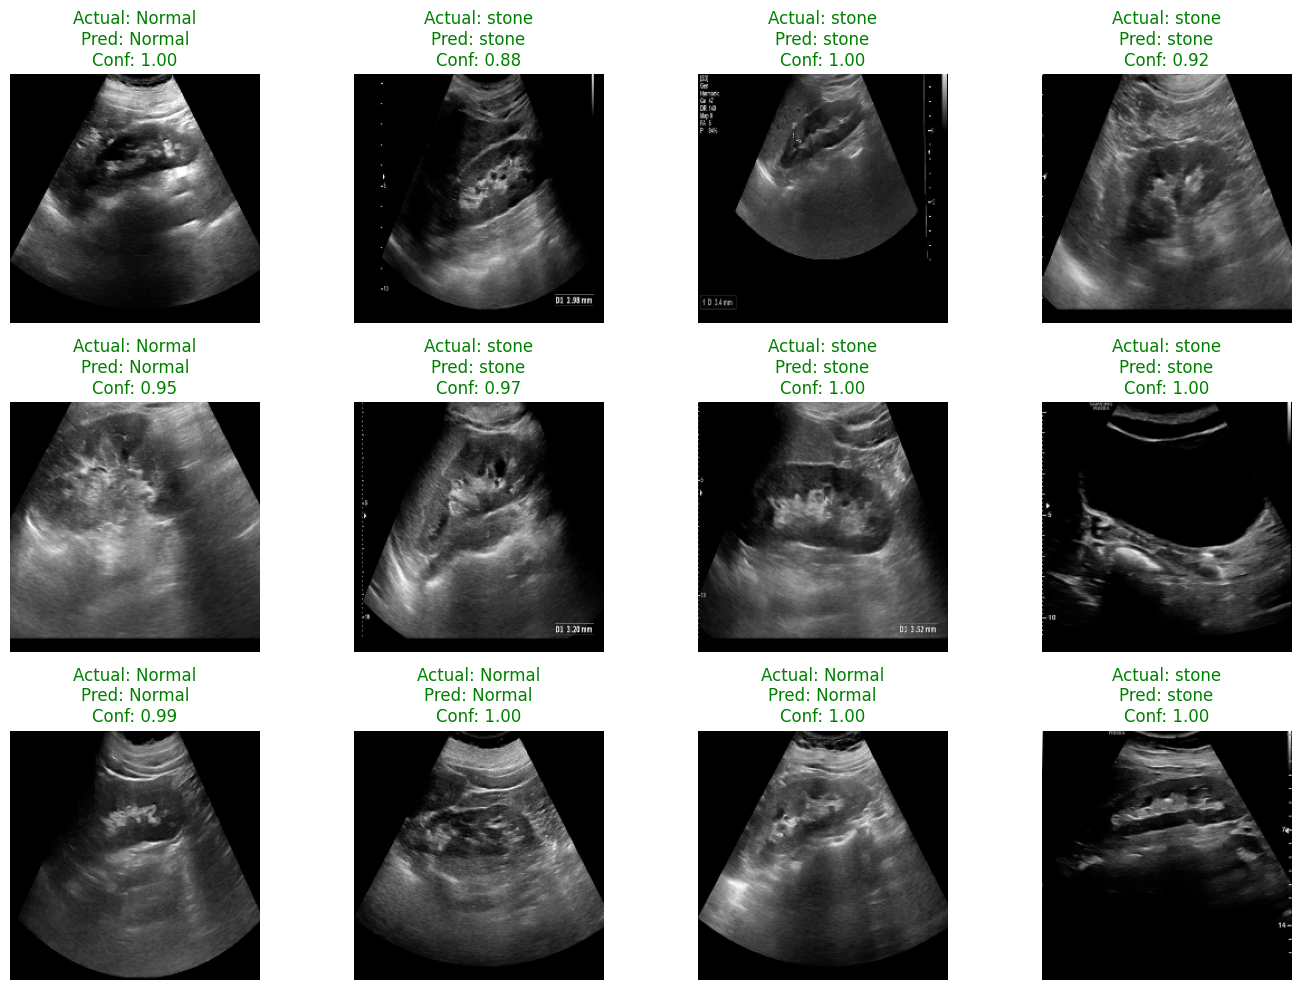

In [33]:


NUM_IMAGES = 12
random_indices = np.random.choice(len(X_test), size=min(NUM_IMAGES, len(X_test)), replace=False)

plt.figure(figsize=(14, 10))

for plot_index, i in enumerate(random_indices):
    image = X_test[i].reshape(IMG_SIZE, IMG_SIZE)

    actual_label = CATEGORIES[y_test[i]]
    predicted_class = int(y_pred_classes_mobile[i][0])
    predicted_label = CATEGORIES[predicted_class]

    confidence = y_pred_prob_mobile[i][0]
    confidence_to_show = confidence if predicted_class == 1 else 1 - confidence

    color = "green" if actual_label == predicted_label else "red"

    plt.subplot(3, 4, plot_index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Actual: {actual_label}\nPred: {predicted_label}\nConf: {confidence_to_show:.2f}",
        color=color
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 17.9. MobileNetV2 Confusion Matrix

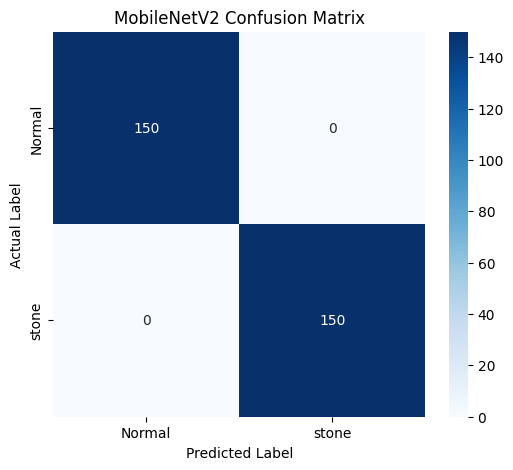

In [34]:


cm_mobile = confusion_matrix(y_test, y_pred_classes_mobile.ravel())

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_mobile,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CATEGORIES,
    yticklabels=CATEGORIES
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# 18. Model Comparison Between Optimized Grayscale CNN and MobileNetV2

## 18.1. Prepare Predictions for Both Models

In [35]:

y_pred_prob_cnn = best_model.predict(X_test)
y_pred_classes_cnn = (y_pred_prob_cnn > 0.5).astype("int32")

y_pred_prob_mobile = model_mobilenet.predict(X_test_mobile)
y_pred_classes_mobile = (y_pred_prob_mobile > 0.5).astype("int32")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


## 18.2. Calculate Accuracy, Loss, ROC-AUC, and Confusion Matrices

In [36]:


cm_cnn = confusion_matrix(y_test, y_pred_classes_cnn.ravel())
cm_mobile = confusion_matrix(y_test, y_pred_classes_mobile.ravel())

fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_pred_prob_cnn.ravel())
auc_cnn = auc(fpr_cnn, tpr_cnn)

fpr_mobile, tpr_mobile, _ = roc_curve(y_test, y_pred_prob_mobile.ravel())
auc_mobile = auc(fpr_mobile, tpr_mobile)

## 18.3. Print Model Comparison Summary

In [37]:


print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

print(f"CNN (Grayscale) Test Accuracy      : {test_accuracy:.4f}")
print(f"MobileNetV2 Test Accuracy          : {acc_mobilenet:.4f}")

print(f"\nCNN (Grayscale) Test Loss          : {test_loss:.4f}")
print(f"MobileNetV2 Test Loss              : {loss_mobilenet:.4f}")

print(f"\nCNN (Grayscale) ROC-AUC            : {auc_cnn:.4f}")
print(f"MobileNetV2 ROC-AUC                : {auc_mobile:.4f}")

print("\nCNN Confusion Matrix:")
print(cm_cnn)

print("\nMobileNetV2 Confusion Matrix:")
print(cm_mobile)

MODEL COMPARISON SUMMARY
CNN (Grayscale) Test Accuracy      : 0.9700
MobileNetV2 Test Accuracy          : 1.0000

CNN (Grayscale) Test Loss          : 0.1735
MobileNetV2 Test Loss              : 0.0165

CNN (Grayscale) ROC-AUC            : 0.9962
MobileNetV2 ROC-AUC                : 1.0000

CNN Confusion Matrix:
[[150   0]
 [  9 141]]

MobileNetV2 Confusion Matrix:
[[150   0]
 [  0 150]]


## 18.4. Comparison Table

In [38]:


comparison_df = pd.DataFrame({
    "Model": ["Optimized Grayscale CNN", "MobileNetV2"],
    "Input Shape": [
        f"{IMG_SIZE}x{IMG_SIZE}x1",
        f"{IMG_SIZE}x{IMG_SIZE}x3"
    ],
    "Test Accuracy": [test_accuracy, acc_mobilenet],
    "Test Loss": [test_loss, loss_mobilenet],
    "ROC-AUC": [auc_cnn, auc_mobile],
    "False Positives": [cm_cnn[0][1], cm_mobile[0][1]],
    "False Negatives": [cm_cnn[1][0], cm_mobile[1][0]]
})

display(comparison_df)

,Model,Input Shape,Test Accuracy,Test Loss,ROC-AUC,False Positives,False Negatives
0,Optimized Grayscale CNN,224x224x1,0.97,0.173516,0.996178,0,9
1,MobileNetV2,224x224x3,1.00,0.016527,1.000000,0,0


## 18.5. Accuracy and ROC-AUC Bar Chart

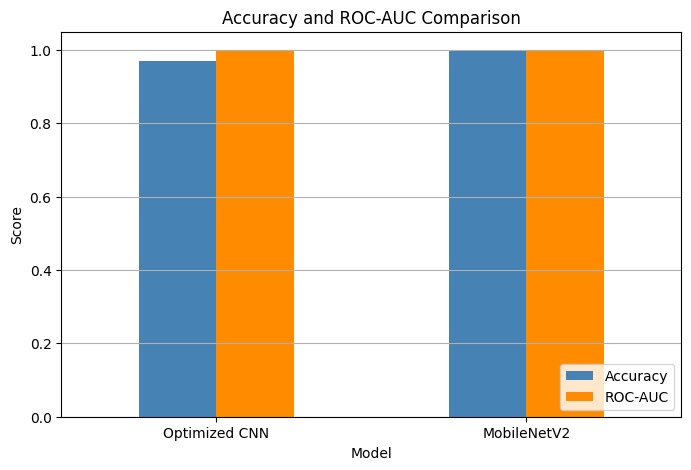

In [39]:


metrics_df = pd.DataFrame({
    "Model": ["Optimized CNN", "MobileNetV2"],
    "Accuracy": [test_accuracy, acc_mobilenet],
    "ROC-AUC": [auc_cnn, auc_mobile]
})

metrics_df.plot(
    x="Model",
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "darkorange"]
)

plt.title("Accuracy and ROC-AUC Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.show()

## 18.6. ROC Curve Comparison

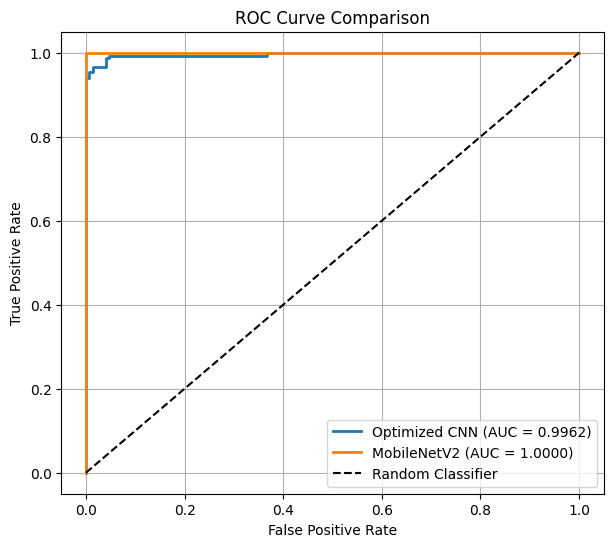

In [40]:


plt.figure(figsize=(7, 6))

plt.plot(
    fpr_cnn,
    tpr_cnn,
    linewidth=2,
    label=f"Optimized CNN (AUC = {auc_cnn:.4f})"
)

plt.plot(
    fpr_mobile,
    tpr_mobile,
    linewidth=2,
    label=f"MobileNetV2 (AUC = {auc_mobile:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 18.7. Confusion Matrix Comparison

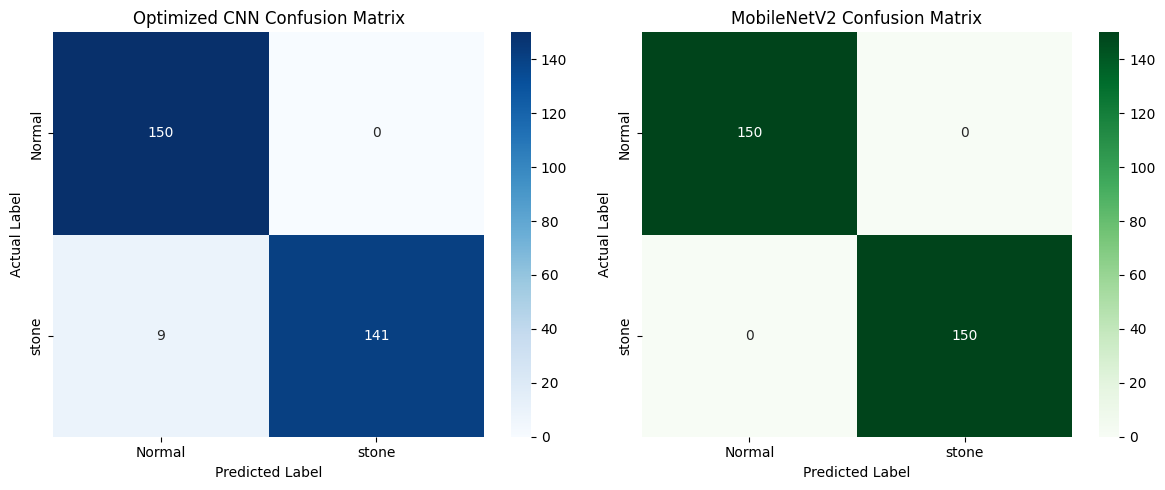

In [41]:


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CATEGORIES,
    yticklabels=CATEGORIES,
    ax=axes[0]
)

axes[0].set_title("Optimized CNN Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

sns.heatmap(
    cm_mobile,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CATEGORIES,
    yticklabels=CATEGORIES,
    ax=axes[1]
)

axes[1].set_title("MobileNetV2 Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

## 18.8. Final Model Decision

In [42]:


print("=" * 70)
print("FINAL MODEL DECISION")
print("=" * 70)

if acc_mobilenet > test_accuracy:
    print("MobileNetV2 performed better based on test accuracy.")
elif test_accuracy > acc_mobilenet:
    print("Optimized Grayscale CNN performed better based on test accuracy.")
else:
    print("Both models achieved the same test accuracy.")

if auc_mobile > auc_cnn:
    print("MobileNetV2 also achieved the higher ROC-AUC score.")
elif auc_cnn > auc_mobile:
    print("Optimized Grayscale CNN achieved the higher ROC-AUC score.")
else:
    print("Both models achieved the same ROC-AUC score.")

print("\nRecommendation:")

if acc_mobilenet >= test_accuracy and auc_mobile >= auc_cnn:
    print("Use MobileNetV2 as the final model for this experiment.")
else:
    print("Use the Optimized Grayscale CNN as the final model for this experiment.")

FINAL MODEL DECISION
MobileNetV2 performed better based on test accuracy.
MobileNetV2 also achieved the higher ROC-AUC score.

Recommendation:
Use MobileNetV2 as the final model for this experiment.
